In [1]:
library(tidyverse)
library(dplyr)
library(extrafont)

theme_rangeframe <- function(size = 0.3) {
    theme(
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )
}

scale_axis_rangeframe <- function() {
    guides(x = "axis_truncated", y = "axis_truncated")
}

rotate_x_text <- function(angle=45) {
    theme(
        axis.text.x = element_text(angle = angle, hjust = 1)
    )
}

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}

no_legend <- function() {
    theme(
        legend.position = "none"
    )
}

custom_theme <- function(size = 0.3){
    theme_minimal() +
    theme(
        text = element_text(family='Helvetica'),
        axis.line = element_line(colour = "black", lineend = "round", size = size),
        axis.ticks = element_line(linewidth = size),
        panel.border = element_blank()
    )
}
theme_set(custom_theme())

article_text <- function() {
    theme(
        text = element_text(size = 5, family = "Helvetica"),
        title = element_text(size = 6),
        axis.text.x = element_text(size = 5),
        axis.text.y = element_text(size = 5)
    )
}

Warning message:
“package ‘tidyverse’ was built under R version 4.2.3”
Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message:
“package ‘readr’ was built under R version 4.2.3”
Warning message:
“package ‘purrr’ was built under R version 4.2.3”
Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
Warning message:
“package ‘stringr’ was built under R version 4.2.3”
Warning message:
“package ‘forcats’ was built under R version 4.2.3”
Warning message:
“package ‘lubridate’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package 

In [2]:
color_dict = c(
    "CellFlow"= "#B12F8C",
    "CellFlow stochastic"= "#B12F8C80",
    "Mean model 1"= "#8F97A8",
    "Mean model 2"= "#566573",
    "Identity"="#BDBDBD",
    "Closest embedding" = "#E0E0E0")

In [3]:
output_dir <- "/lustre/groups/ml01/workspace/ot_perturbation/figures/pbmc/cellflow_stochastic"

In [4]:
df <- read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/results/allocation/metrics_new_cytokine_with_stochastic.csv")

New names:
• `` -> `...1`
Rows: 720 Columns: 253
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): ...1, donor_cytokine, donor, cytokine, mode, method, Unnamed: 0.1...
dbl (241): ood_e_distance_0, decoded_ood_r_squared_0, ood_e_distance_1, deco...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [5]:
table(df$method)


      cf cf_stoch       cl       id       m1 
     144      144      144      144      144 

In [6]:
df$method <- factor(df$method, 
                                levels = c("id", "m1", "m2", "cl", "cf", "cf_stoch"),
                                labels = c("Identity", "Mean model 1", "Mean model 2", "Closest embedding", "CellFlow", "CellFlow stochastic"))

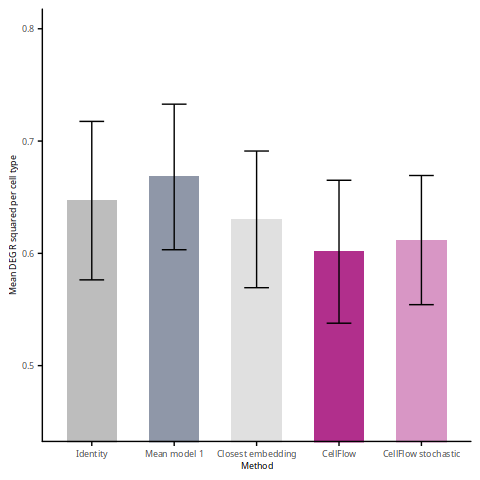

In [7]:
options(repr.plot.width = 4.0, repr.plot.height = 4.0, unit = "cm")

df_summary <- df %>%
  group_by(method) %>%
  summarise(
    mean_val = mean(mean_deg_r_sq_per_cell_type, na.rm = TRUE),
    se = sd(mean_deg_r_sq_per_cell_type, na.rm = TRUE) / sqrt(n()),
    .groups = 'drop'
  )

p <- ggplot(df_summary, aes(x = method, y = mean_val, fill = method)) +
  geom_bar(
    stat = "identity",
    width = 0.6
  ) +
  geom_errorbar(
    aes(ymin = mean_val - 1.96 * se, ymax = mean_val + 1.96 * se),
    width = 0.3,
    linewidth = 0.3
  ) +
  labs(
    x = "Method",
    y = "Mean DEG R squared per cell type"
  ) +
  scale_fill_manual(values = color_dict) +
  custom_theme() +
  article_text() +
  no_legend() +
  theme(
    axis.title.x = element_text(size = 5),
    axis.title.y = element_text(size = 5),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) +
  coord_cartesian(ylim = c(0.45, 0.8))

p

In [8]:
ggsave(file.path(output_dir, "barplot_r_squared_deg_per_cell_type.pdf"), plot = p, device = "pdf", width = 4.0, height = 4.0, unit = "cm")

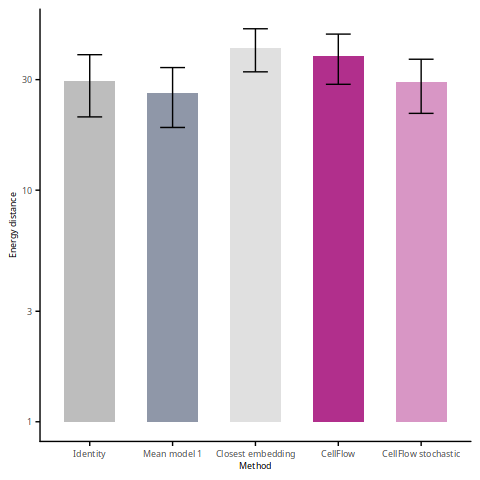

In [9]:
options(repr.plot.width = 4.0, repr.plot.height = 4.0, unit = "cm")

df_summary <- df %>%
  group_by(method) %>%
  summarise(
    mean_val = mean(mean_ood_e_distance, na.rm = TRUE),
    se = sd(mean_ood_e_distance, na.rm = TRUE) / sqrt(n()),
    .groups = 'drop'
  )

p <- ggplot(df_summary, aes(x = method, y = mean_val, fill = method)) +
  geom_bar(
    stat = "identity",
    width = 0.6
  ) +
  geom_errorbar(
    aes(ymin = mean_val - 1.96 * se, ymax = mean_val + 1.96 * se),
    width = 0.3,
    linewidth = 0.3
  ) +
  labs(
    x = "Method",
    y = "Energy distance"
  ) +
  scale_y_log10() +
  scale_fill_manual(values = color_dict) +
  custom_theme() +
  article_text() +
  no_legend() +
  theme(
    axis.title.x = element_text(size = 5),
    axis.title.y = element_text(size = 5),
    axis.text.x  = element_text(size = 5),
    axis.text.y  = element_text(size = 5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )

p

In [10]:
ggsave(file.path(output_dir, "barplot_e_distance.pdf"), plot = p, device = "pdf", width = 4.0, height = 4.0, unit = "cm")